In [3]:
from tensorflow import keras
from keras.models import Model
from keras.layers import Flatten, Dense, Input, Conv2D, MaxPooling2D, GlobalMaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # Correct import
from keras.applications.resnet import ResNet50
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import pandas as pd

In [6]:
!pip install --upgrade --force-reinstall "protobuf<=3.20.3"

  Using cached protobuf-3.20.3-py2.py3-none-any.whl (162 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.4
    Uninstalling protobuf-4.25.4:
      Successfully uninstalled protobuf-4.25.4


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\user\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\google\\~upb\\_message.pyd'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip available: 22.3 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
dataset_path = '/kaggle/input/uot32-underwater-object-tracking-dataset/'

# ImageDataGenerator for loading images in batches
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.33)  # Normalization + validation split


In [6]:
# Training and validation generators
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=64,  # Load images in batches of 32 to avoid memory issues
    class_mode='sparse',
    subset='training'  # Use this subset for training
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,  # Use the same batch size for validation
    class_mode='sparse',
    subset='validation'  # Use this subset for validation
)


Found 17757 images belonging to 32 classes.
Found 8721 images belonging to 32 classes.


**EfficientNetB0**

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

num_classes = 32

# Load EfficientNetB0 WITHOUT imagenet weights
base_model = EfficientNetB0(
    include_top=False,
    weights=None,          # IMPORTANT FIX
    input_shape=(224, 224, 3)
)

base_model.trainable = True  # You can train entire model since weights are random

x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.3)(x)
outputs = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

: 

In [9]:
import warnings
warnings.filterwarnings('ignore')

In [10]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=1
)

I0000 00:00:1764486522.705684     134 service.cc:148] XLA service 0x7f90f8002c80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764486522.706631     134 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1764486522.706654     134 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1764486527.498074     134 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1764486541.527350     134 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764486541.684109     134 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764486542.316085     134 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. Th

 63/278 ━━━━━━━━━━━━━━━━━━━━ 2:19 648ms/step - accuracy: 0.3789 - loss: 2.3077

E0000 00:00:1764486616.270374     133 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764486616.414505     133 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764486616.857843     133 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764486616.999147     133 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


278/278 ━━━━━━━━━━━━━━━━━━━━ 402s 1s/step - accuracy: 0.6788 - loss: 1.1216 - val_accuracy: 0.0258 - val_loss: 8.8108


In [11]:
model.save("efficientnet_b0_underwater.h5")
print("Model saved successfully!")

Model saved successfully!


In [12]:
from tensorflow.keras.models import load_model

model = load_model("efficientnet_b0_underwater.h5")
print("Model loaded successfully!")


Model loaded successfully!


In [16]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# Load saved model
model = load_model("efficientnet_b0_underwater.h5")

# Class names (same order as train_generator)
class_names = list(train_generator.class_indices.keys())

# Video input path
video_path = "/kaggle/input/uot32-underwater-object-tracking-dataset/ArmyDiver1/ArmyDiver1.mp4"

# Open video
cap = cv2.VideoCapture(video_path)

# Output video writer
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter("classified_output.mp4", fourcc, 30, 
                      (int(cap.get(3)), int(cap.get(4))))

print("Processing video...")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Preprocess frame
    img = cv2.resize(frame, (224, 224))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)

    # Predict class
    preds = model.predict(img, verbose=0)
    class_id = np.argmax(preds)
    label = class_names[class_id]

    # Draw prediction on frame
    cv2.putText(frame, f"Class: {label}", 
                (20, 40), cv2.FONT_HERSHEY_SIMPLEX,
                1.1, (0, 255, 0), 3)

    # Write to output video
    out.write(frame)

cap.release()
out.release()

print("Finished! Output video saved as classified_output.mp4")


Processing video...
Finished! Output video saved as classified_output.mp4


**Custom CNN**

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, ReLU, MaxPool2D,
    GlobalAveragePooling2D, Dense, Dropout, AveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import os

In [14]:
IMG_SHAPE = (224, 224, 3)
NUM_CLASSES = 32           # as you indicated
LR = 1e-3
EPOCHS = 1
MODEL_SAVE_PATH = "custom_cnn_uot32.h5"
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)


In [15]:
# --- Model definition: compact but expressive CNN ---
def build_custom_cnn(input_shape=IMG_SHAPE, num_classes=NUM_CLASSES):
    inp = Input(shape=input_shape)

    # Block 1
    x = Conv2D(32, (3,3), padding="same", kernel_initializer="he_normal")(inp)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Conv2D(32, (3,3), padding="same", kernel_initializer="he_normal")(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPool2D((2,2))(x)   # 112

    # Block 2
    x = Conv2D(64, (3,3), padding="same", kernel_initializer="he_normal")(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Conv2D(64, (3,3), padding="same", kernel_initializer="he_normal")(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPool2D((2,2))(x)   # 56

    # Block 3
    x = Conv2D(128, (3,3), padding="same", kernel_initializer="he_normal")(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Conv2D(128, (3,3), padding="same", kernel_initializer="he_normal")(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPool2D((2,2))(x)   # 28

    # Block 4 (dilated / deeper)
    x = Conv2D(256, (3,3), padding="same", kernel_initializer="he_normal")(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = AveragePooling2D((2,2))(x)  # 14

    # Head
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)
    x = Dense(256, activation="relu", kernel_initializer="he_normal")(x)
    x = Dropout(0.35)(x)
    out = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=inp, outputs=out, name="custom_cnn_uot32")
    return model

# Build & compile
model = build_custom_cnn()
model.compile(
    optimizer=Adam(learning_rate=LR),
    loss="sparse_categorical_crossentropy",   # your generators use sparse labels
    metrics=["accuracy"]
)

# Print model summary
model.summary()


Model: "custom_cnn_uot32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             

 Total params: 659,008 (2.51 MB)

 Trainable params: 657,600 (2.51 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [16]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(MODEL_SAVE_PATH, monitor="val_accuracy", save_best_only=True, verbose=1)
]

# --- Compute steps (robust to generators with shuffle) ---
train_steps = max(1, train_generator.samples // train_generator.batch_size)
val_steps = max(1, validation_generator.samples // validation_generator.batch_size)


In [17]:
# --- Train ---
history = model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    validation_data=validation_generator,
    validation_steps=val_steps,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)


2025-11-30 07:17:40.923488: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng0{} for conv (f32[32,32,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,32,224,224]{3,2,1,0}, f32[64,32,224,224]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-11-30 07:17:51.927043: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 12.003673441s
Trying algorithm eng0{} for conv (f32[32,32,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,32,224,224]{3,2,1,0}, f32[64,32,224,224]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", backend_config={"cudnn_conv_backend_config":{"ac

277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.6970 - loss: 1.0192
Epoch 1: val_accuracy improved from -inf to 0.76861, saving model to custom_cnn_uot32.h5


277/277 ━━━━━━━━━━━━━━━━━━━━ 225s 662ms/step - accuracy: 0.6975 - loss: 1.0174 - val_accuracy: 0.7686 - val_loss: 0.7442 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 1.


In [18]:
model.save("custom_cnn_uot32_final.h5")
print("Final model saved to custom_cnn_uot32_final.h5")
# Best model (from checkpoint) is at MODEL_SAVE_PATH
if os.path.exists(MODEL_SAVE_PATH):
    print(f"Best checkpoint saved at: {MODEL_SAVE_PATH}")

Final model saved to custom_cnn_uot32_final.h5
Best checkpoint saved at: custom_cnn_uot32.h5


In [19]:
efficientnet_path = "/kaggle/working/efficientnet_b0_underwater.h5"
customcnn_path = "/kaggle/working/custom_cnn_uot32_final.h5"

eff_model = load_model(efficientnet_path)
cnn_model = load_model(customcnn_path)

print("EfficientNet Model Loaded.")
print("Custom CNN Model Loaded.")

EfficientNet Model Loaded.
Custom CNN Model Loaded.


In [20]:
# -------------------------------
# Remove original classification heads
# -------------------------------

# Get input shape from EfficientNet (both must match)
input_shape = eff_model.input_shape[1:]

# Cut the EfficientNet features
eff_features = eff_model.layers[-3].output  # last conv or GAP layer
if len(eff_features.shape) == 4:            # if conv feature map
    eff_features = GlobalAveragePooling2D()(eff_features)

# Cut the Custom CNN features
cnn_features = cnn_model.layers[-3].output
if len(cnn_features.shape) == 4:
    cnn_features = GlobalAveragePooling2D()(cnn_features)


In [21]:
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [22]:
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout, Concatenate
from tensorflow.keras.optimizers import Adam

num_classes = 32

# ------------------------------
# Load your models
# ------------------------------
efficientnet = load_model("/kaggle/working/efficientnet_b0_underwater.h5")
customcnn = load_model("/kaggle/working/custom_cnn_uot32_final.h5")

# Freeze or unfreeze depending on training preference
efficientnet.trainable = True
customcnn.trainable = True

# ------------------------------
# Create new shared input
# ------------------------------
inp = Input(shape=(224, 224, 3))

# ------------------------------
# Pass the input into both models
# ------------------------------

eff_out = efficientnet(inp)
cnn_out = customcnn(inp)

# If models output logits, remove classifier layers manually
if len(eff_out.shape) == 2 and eff_out.shape[-1] != 32:
    eff_out = GlobalAveragePooling2D()(efficientnet.layers[-3].output)

if len(cnn_out.shape) == 2 and cnn_out.shape[-1] != 32:
    cnn_out = GlobalAveragePooling2D()(customcnn.layers[-3].output)

# If models output feature maps (4D), apply pooling
if len(eff_out.shape) == 4:
    eff_out = GlobalAveragePooling2D()(eff_out)

if len(cnn_out.shape) == 4:
    cnn_out = GlobalAveragePooling2D()(cnn_out)

# ------------------------------
# Feature Fusion
# ------------------------------
merged = Concatenate()([eff_out, cnn_out])
merged = Dense(512, activation='relu')(merged)
merged = Dropout(0.4)(merged)
merged = Dense(128, activation='relu')(merged)
merged = Dropout(0.3)(merged)

output = Dense(num_classes, activation='softmax')(merged)

# ------------------------------
# Build hybrid model
# ------------------------------
hybrid_model = Model(inputs=inp, outputs=output)

hybrid_model.compile(
    optimizer=Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

hybrid_model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_1        │ (None, 32)        │  4,090,563 │ input_layer_3[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_cnn_uot32    │ (None, 32)        │    659,008 │ input_layer_3[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ functional_1[0][… │
│ (Concatenate)       │                   │            │ custom_cnn_uot32… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 512)       │     33,280 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 512)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     65,664 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │      4,128 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,852,643 (18.51 MB)

 Trainable params: 4,809,212 (18.35 MB)

 Non-trainable params: 43,431 (169.66 KB)

In [23]:
# Train model
history = hybrid_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15,
    verbose=1
)

# Save model in the NEW Keras format (recommended)
hybrid_model.save("hybrid_combined_model.keras")
print("Hybrid model saved successfully.")

# Print best validation accuracy
print("Best Validation Accuracy:", max(history.history["val_accuracy"]))


Epoch 1/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 317s 882ms/step - accuracy: 0.3842 - loss: 3.1753 - val_accuracy: 0.6676 - val_loss: 2.5896
Epoch 2/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 197s 707ms/step - accuracy: 0.9264 - loss: 1.2965 - val_accuracy: 0.9747 - val_loss: 0.3431
Epoch 3/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 197s 707ms/step - accuracy: 0.9744 - loss: 0.3100 - val_accuracy: 0.9799 - val_loss: 0.0869
Epoch 4/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 197s 709ms/step - accuracy: 0.9757 - loss: 0.1278 - val_accuracy: 0.9758 - val_loss: 0.0703
Epoch 5/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 196s 706ms/step - accuracy: 0.9783 - loss: 0.0765 - val_accuracy: 0.9758 - val_loss: 0.0665
Epoch 6/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 196s 704ms/step - accuracy: 0.9774 - loss: 0.0627 - val_accuracy: 0.9763 - val_loss: 0.0542
Epoch 7/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 195s 700ms/step - accuracy: 0.9788 - loss: 0.0505 - val_accuracy: 0.9764 - val_loss: 0.0599
Epoch 8/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 196s 702ms/step - accuracy: 0.9780 -

============== Training Summary ==============
Best Training Accuracy: 0.9790 at epoch 7
Best Validation Accuracy: 0.9799 at epoch 3
Lowest Training Loss: 0.0366 at epoch 15
Lowest Validation Loss: 0.0405 at epoch 9



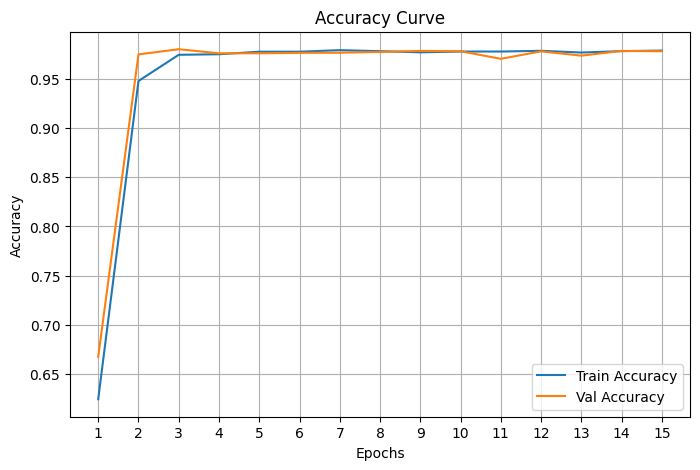

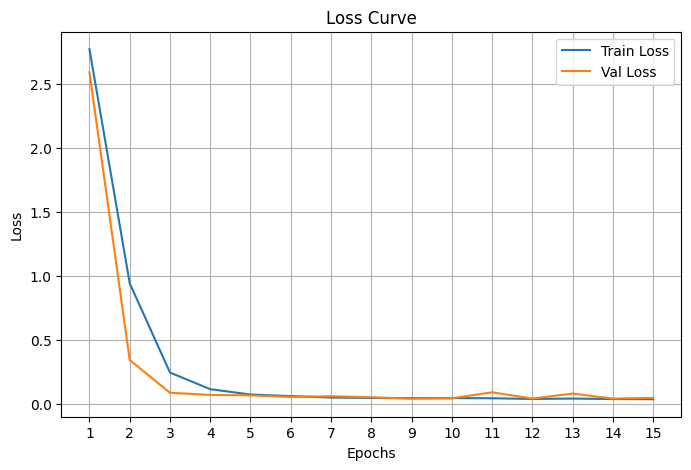

In [41]:
import matplotlib.pyplot as plt

def plot_training(history):
    # Prepare epoch numbers (1 to N)
    epochs = range(1, len(history.history['accuracy']) + 1)

    # --------------------------
    # Print Best Metrics
    # --------------------------
    best_train_acc = max(history.history['accuracy'])
    best_val_acc = max(history.history['val_accuracy'])
    best_train_acc_epoch = history.history['accuracy'].index(best_train_acc) + 1
    best_val_acc_epoch = history.history['val_accuracy'].index(best_val_acc) + 1

    lowest_train_loss = min(history.history['loss'])
    lowest_val_loss = min(history.history['val_loss'])
    lowest_train_loss_epoch = history.history['loss'].index(lowest_train_loss) + 1
    lowest_val_loss_epoch = history.history['val_loss'].index(lowest_val_loss) + 1

    print("============== Training Summary ==============")
    print(f"Best Training Accuracy: {best_train_acc:.4f} at epoch {best_train_acc_epoch}")
    print(f"Best Validation Accuracy: {best_val_acc:.4f} at epoch {best_val_acc_epoch}")
    print(f"Lowest Training Loss: {lowest_train_loss:.4f} at epoch {lowest_train_loss_epoch}")
    print(f"Lowest Validation Loss: {lowest_val_loss:.4f} at epoch {lowest_val_loss_epoch}")
    print("==============================================\n")

    # --------------------------
    # Accuracy Plot
    # --------------------------
    plt.figure(figsize=(8,5))
    plt.plot(epochs, history.history['accuracy'], label='Train Accuracy')
    plt.plot(epochs, history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.xticks(epochs)
    plt.legend()
    plt.grid(True)
    plt.show()

    # --------------------------
    # Loss Plot
    # --------------------------
    plt.figure(figsize=(8,5))
    plt.plot(epochs, history.history['loss'], label='Train Loss')
    plt.plot(epochs, history.history['val_loss'], label='Val Loss')
    plt.title('Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.xticks(epochs)
    plt.legend()
    plt.grid(True)
    plt.show()

# Call function
plot_training(history)


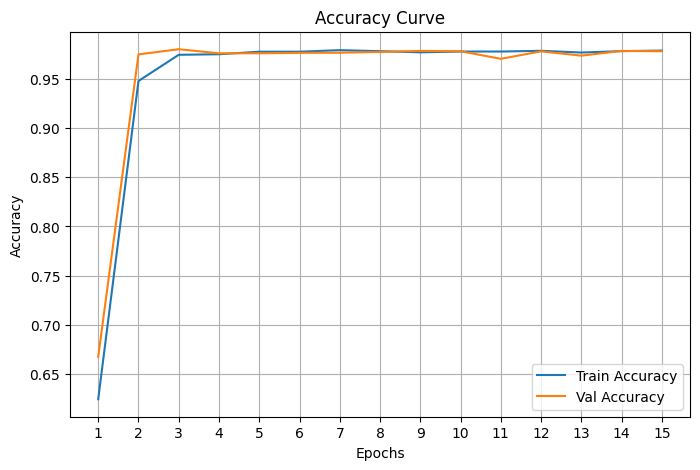

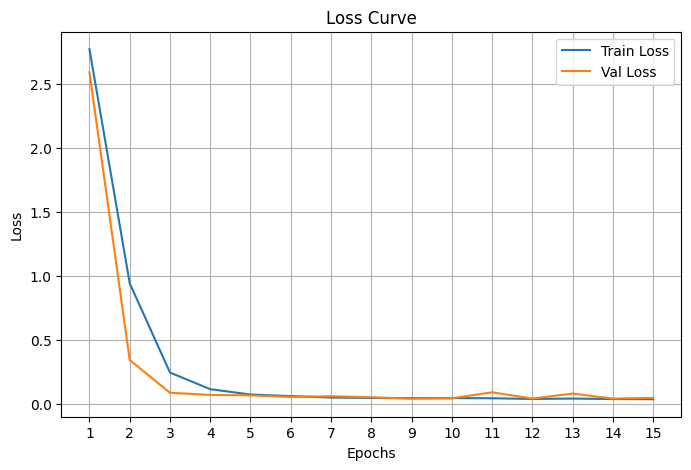

In [27]:
import matplotlib.pyplot as plt

def plot_training(history):
    # Prepare epoch numbers (1 to N)
    epochs = range(1, len(history.history['accuracy']) + 1)

    # Accuracy
    plt.figure(figsize=(8,5))
    plt.plot(epochs, history.history['accuracy'], label='Train Accuracy')
    plt.plot(epochs, history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.xticks(epochs)  # Show all epoch numbers
    plt.legend()
    plt.grid(True)
    plt.show()

    # Loss
    plt.figure(figsize=(8,5))
    plt.plot(epochs, history.history['loss'], label='Train Loss')
    plt.plot(epochs, history.history['val_loss'], label='Val Loss')
    plt.title('Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.xticks(epochs)  # Show all epoch numbers
    plt.legend()
    plt.grid(True)
    plt.show()

plot_training(history)


273/273 ━━━━━━━━━━━━━━━━━━━━ 48s 176ms/step


<Figure size 1000x700 with 0 Axes>

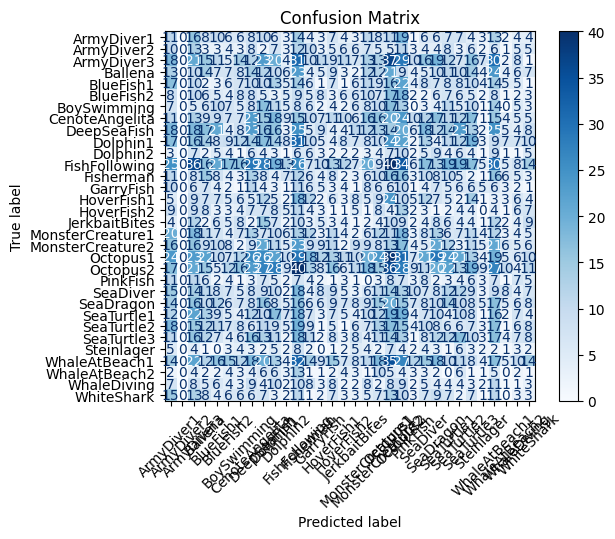

In [32]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = hybrid_model.predict(validation_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
true_classes = validation_generator.classes
class_labels = list(validation_generator.class_indices.keys())

cm = confusion_matrix(true_classes, y_pred_classes)

plt.figure(figsize=(10,7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


In [34]:
from sklearn.metrics import classification_report

print(classification_report(true_classes, y_pred_classes, target_names=class_labels))


                  precision    recall  f1-score   support

      ArmyDiver1       0.02      0.04      0.03       225
      ArmyDiver2       0.00      0.00      0.00       173
      ArmyDiver3       0.06      0.06      0.06       442
         Ballena       0.03      0.03      0.03       300
       BlueFish1       0.06      0.06      0.06       250
       BlueFish2       0.04      0.04      0.04       195
     BoySwimming       0.03      0.03      0.03       213
  CenoteAngelita       0.04      0.04      0.04       365
     DeepSeaFish       0.03      0.03      0.03       391
        Dolphin1       0.06      0.05      0.06       355
        Dolphin2       0.01      0.02      0.01       128
   FishFollowing       0.07      0.07      0.07       551
       Fisherman       0.03      0.03      0.03       233
       GarryFish       0.01      0.01      0.01       155
      HoverFish1       0.03      0.03      0.03       222
      HoverFish2       0.03      0.03      0.03       148
   JerkbaitBi

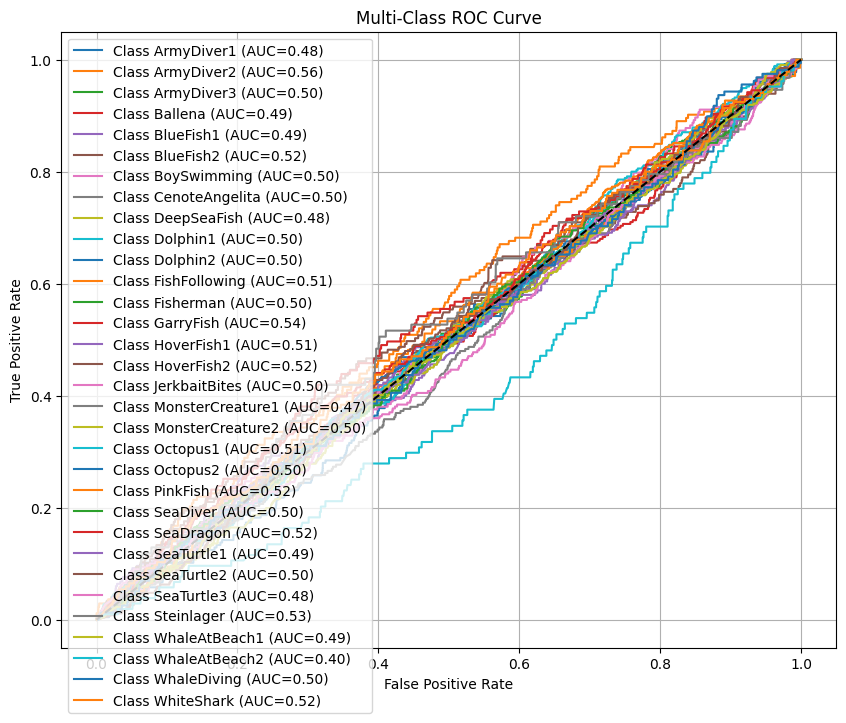

In [35]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(true_classes, classes=range(len(class_labels)))
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(10,8))

for i in range(len(class_labels)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f"Class {class_labels[i]} (AUC={roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


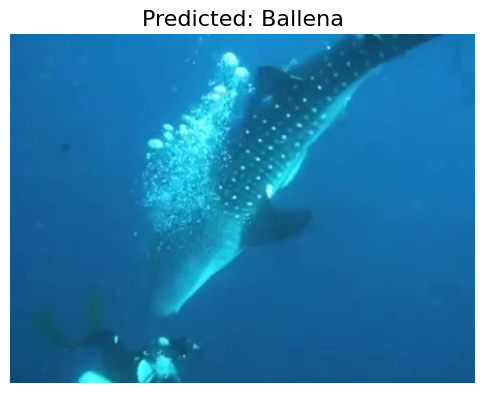

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Path to your test image
img_path = "/kaggle/input/uot32-underwater-object-tracking-dataset/Ballena/img/10.jpg"

# Input size for your hybrid model
img_size = (224, 224)

# Load & preprocess
img = image.load_img(img_path, target_size=img_size)
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0  # normalize (same as training)

# Predict
pred = hybrid_model.predict(img_array)
pred_class = np.argmax(pred, axis=1)[0]

# Class names from your dataset
class_labels = [
    'ArmyDiver1','ArmyDiver2','ArmyDiver3','Ballena', 'BlueFish1','BlueFish2','BoySwimming','CenoteAngelita','DeepSeaFish','Dolphin1','Dolphin2','FishFollowing',
    'Fisherman','GarryFish','HoverFish1','HoverFish2','JerkbaitBites','MonsterCreature1','MonsterCreature2','Octopus1','Octopus2','PinkFish','SeaDiver','SeaDragon',
    'SeaTurtle1','SeaTurtle2','SeaTurtle3','Steinlager','WhaleAtBeach1','WhaleAtBeach2','WhaleDiving','WhiteShark'
    
]
pred_label = class_labels[pred_class]

# Display Image with prediction
plt.figure(figsize=(6, 6))
plt.imshow(image.load_img(img_path))
plt.title(f"Predicted: {pred_label}", fontsize=16)
plt.axis("off")
plt.show()
